In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df=pd.read_csv("UpdatedResumeDataSet.csv")

In [5]:
df


,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."
...,...,...
957,Testing,Computer Skills: â¢ Proficient in MS office (...
958,Testing,â Willingness to accept the challenges. â ...
959,Testing,"PERSONAL SKILLS â¢ Quick learner, â¢ Eagerne..."
960,Testing,COMPUTER SKILLS & SOFTWARE KNOWLEDGE MS-Power ...


In [6]:
df.shape

(962, 2)

In [7]:
print(type(df["Category"].value_counts()))

<class 'pandas.core.series.Series'>


In [8]:
df["Category"].value_counts()

Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Blockchain                   40
ETL Developer                40
Operations Manager           40
Data Science                 40
Sales                        40
Mechanical Engineer          40
Arts                         36
Database                     33
Electrical Engineering       30
Health and fitness           30
PMO                          30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
SAP Developer                24
Civil Engineer               24
Advocate                     20
Name: count, dtype: int64

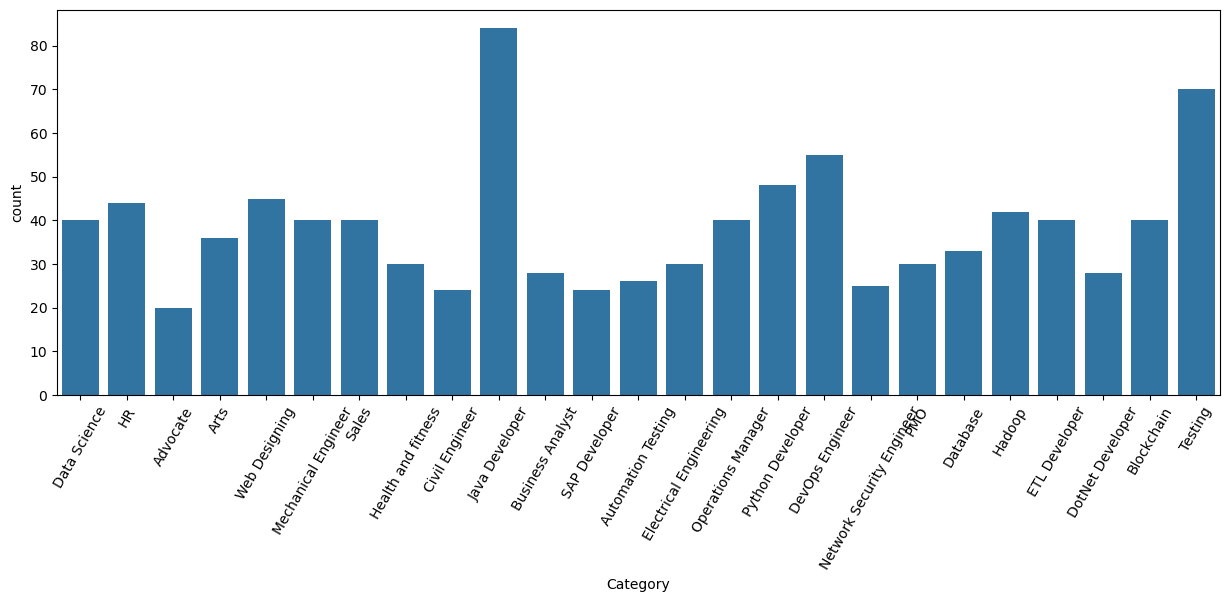

In [9]:
plt.figure(figsize=(15,5))
sns.countplot(data=df,x=df["Category"])
plt.xticks(rotation=60)
plt.show()


In [10]:
counts=df["Category"].value_counts()
label=df["Category"].unique()

([<matplotlib.patches.Wedge at 0x1f2bf4c6cf0>,
 [Text(1.058871227218848, 0.29797940225467084, 'Data Science'),
  Text(0.7841417277955074, 0.7714413462667635, 'HR'),
  Text(0.41347312332933783, 1.0193331036929403, 'Advocate'),
  Text(0.053862303159734344, 1.0986805051052508, 'Arts'),
  Text(-0.27717597647551645, 1.0645062132579801, 'Web Designing'),
  Text(-0.5706079221763859, 0.9404289442321242, 'Mechanical Engineer'),
  Text(-0.8089120194310812, 0.7454269547178518, 'Sales'),
  Text(-0.9773197556910534, 0.5048228353947349, 'Health and fitness'),
  Text(-1.0745481947062527, 0.23525768266633296, 'Civil Engineer'),
  Text(-1.0988505276751686, -0.05027442518820011, 'Java Developer'),
  Text(-1.0485773817141402, -0.3323935537243749, 'Business Analyst'),
  Text(-0.9271404255154017, -0.5919549234317762, 'SAP Developer'),
  Text(-0.7427816407083776, -0.8113417493427605, 'Automation Testing'),
  Text(-0.5207133706140742, -0.9689466371600295, 'Electrical Engineering'),
  Text(-0.2910572162881381

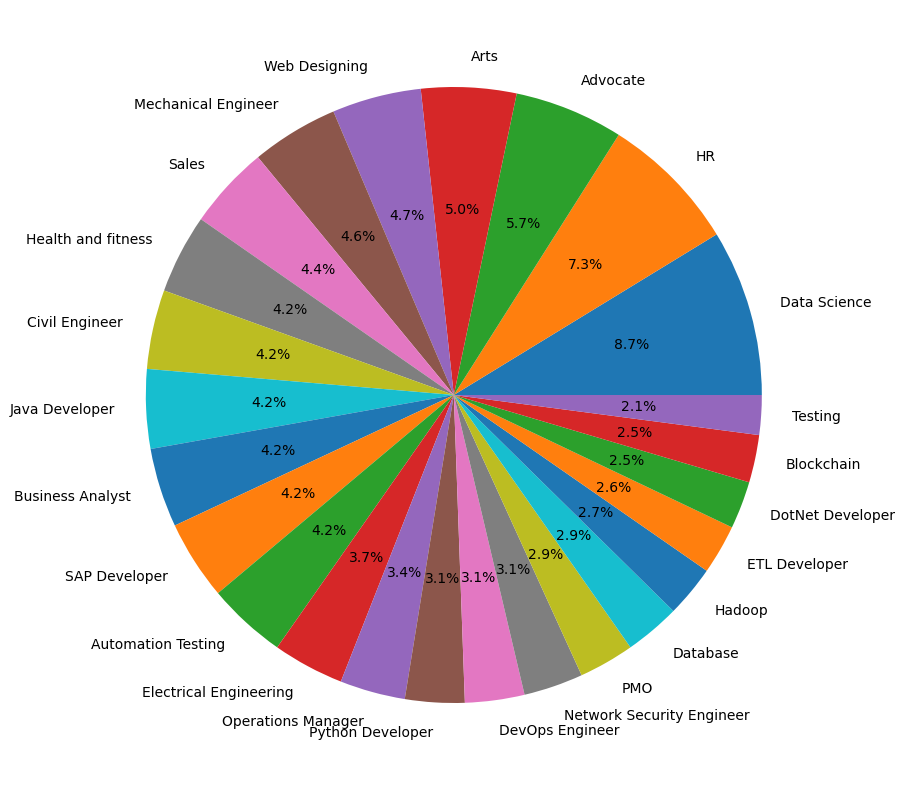

In [11]:
plt.figure(figsize=(18,10))
plt.pie(counts,labels=label, autopct="%1.1f%%",)

Exploring Resume

In [12]:
df["Resume"][0]

'Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regression, SVM, NaÃ¯ve Bayes, KNN, Random Forest, Decision Trees, Boosting techniques, Cluster Analysis, Word Embedding, Sentiment Analysis, Natural Language processing, Dimensionality reduction, Topic Modelling (LDA, NMF), PCA & Neural Nets. * Database Visualizations: Mysql, SqlServer, Cassandra, Hbase, ElasticSearch D3.js, DC.js, Plotly, kibana, matplotlib, ggplot, Tableau. * Others: Regular Expression, HTML, CSS, Angular 6, Logstash, Kafka, Python Flask, Git, Docker, computer vision - Open CV and understanding of Deep learning.Education Details \r\n\r\nData Science Assurance Associate \r\n\r\nData Science Assurance Associate - Ernst & Young LLP\r\nSkill Details \r\nJAVASCRIPT- Exprience - 24 months\r\njQuery- Exprience - 24 months\r\nPython- Exprience - 24 monthsCompany Details \r\ncompany - Ernst & Young LLP\r\ndescription - Fraud Investigatio

Cleaning Data


1) urls
2) hashtag
3) mentions
4) special items
5) puncations
   

In [13]:
import re

def CleanResume(txt):
    # Remove http/https links
    txt = re.sub(r"http[s]?://\S+", " ", txt)
    
    # Remove carriage returns and newlines
    txt = re.sub(r"[\r\n]+", " ", txt)
    
    # Remove non-ASCII artifacts (like â\x80¢)
    txt = re.sub(r"[^\x00-\x7F]+", " ", txt)
    
    # Remove ALL non-letters (keep only a-z, A-Z, spaces)
    txt = re.sub(r"[^a-zA-Z ]", " ", txt)
    
    # Collapse multiple spaces into one
    txt = re.sub(r"\s+", " ", txt).strip()
    
    return txt



    


In [14]:

CleanResume(df["Resume"][9])

'Expertise Data and Quantitative Analysis Decision Analytics Predictive Modeling Data Driven Personalization KPI Dashboards Big Data Queries and Interpretation Data Mining and Visualization Tools Machine Learning Algorithms Business Intelligence BI Research Reports and Forecasts Education Details PGP in Data Science Mumbai Maharashtra Aegis School of data science Business B E in Electronics Communication Electronics Communication Indore Madhya Pradesh IES IPS Academy Data Scientist Data Scientist with PR Canada Skill Details Algorithms Exprience months BI Exprience months Business Intelligence Exprience months Machine Learning Exprience months Visualization Exprience months spark Exprience months python Exprience months tableau Exprience months Data Analysis Exprience monthsCompany Details company Aegis school of Data Science Business description Mostly working on industry project for providing solution along with Teaching Appointments Teach undergraduate and graduate level courses in 

In [15]:
df["Resume"]=df["Resume"].apply(lambda x:CleanResume(x))

In [16]:
df["Resume"]


0      Skills Programming Languages Python pandas num...
1      Education Details May to May B E UIT RGPV Data...
2      Areas of Interest Deep Learning Control System...
3      Skills R Python SAP HANA Tableau SAP HANA SQL ...
4      Education Details MCA YMCAUST Faridabad Haryan...
                             ...                        
957    Computer Skills Proficient in MS office Word B...
958    Willingness to accept the challenges Positive ...
959    PERSONAL SKILLS Quick learner Eagerness to lea...
960    COMPUTER SKILLS SOFTWARE KNOWLEDGE MS Power Po...
961    Skill Set OS Windows XP Database MYSQL sql ser...
Name: Resume, Length: 962, dtype: object

In [17]:
# Words into categorical Values

In [18]:
df["Category"].unique()

array(['Data Science', 'HR', 'Advocate', 'Arts', 'Web Designing',
       'Mechanical Engineer', 'Sales', 'Health and fitness',
       'Civil Engineer', 'Java Developer', 'Business Analyst',
       'SAP Developer', 'Automation Testing', 'Electrical Engineering',
       'Operations Manager', 'Python Developer', 'DevOps Engineer',
       'Network Security Engineer', 'PMO', 'Database', 'Hadoop',
       'ETL Developer', 'DotNet Developer', 'Blockchain', 'Testing'],
      dtype=object)

In [19]:
from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()

In [20]:
le.fit(df["Category"])
df["Category"]=le.transform(df["Category"])


In [21]:
df["Category"].unique()

array([ 6, 12,  0,  1, 24, 16, 22, 14,  5, 15,  4, 21,  2, 11, 18, 20,  8,
       17, 19,  7, 13, 10,  9,  3, 23])

VECTORIZATION



In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(stop_words='english')
X=tfidf.fit_transform(df["Resume"])

In [23]:
X


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 158292 stored elements and shape (962, 7036)>

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
X_train,X_test,y_train,y_test=train_test_split(
    X,df["Category"],test_size=0.33,random_state=42
                                              )

In [26]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multiclass import OneVsRestClassifier

clf=OneVsRestClassifier(KNeighborsClassifier())
clf.fit(X_train,y_train)


,estimator,KNeighborsClassifier()
,n_jobs,None
,verbose,0
,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [27]:

y_pred=clf.predict(X_test)
y_pred

array([15, 15, 15, 13, 14, 17, 16,  2,  0, 14, 13, 12, 16, 23, 20,  5,  6,
        4, 10,  9, 19,  1, 10, 23, 23, 21, 22, 22,  2, 12, 18,  1,  8, 24,
       11, 23,  7, 12, 24,  8, 18,  6,  8, 19, 24, 23, 21,  1, 15,  4, 15,
       22, 11,  5, 15, 13,  1, 19,  5, 12, 22, 22, 20, 24, 21, 18, 12, 10,
       10, 20, 10,  8,  9, 21, 17, 21,  0, 17, 16, 14, 15, 11, 11,  8, 20,
        3, 19,  8,  0,  2,  9, 10,  2, 23, 20, 20, 23, 12, 18, 12,  7, 16,
        8, 14, 18,  3, 14, 19, 14, 14, 15, 18,  8,  2, 21, 18, 23, 10, 23,
        5, 11, 15, 12,  3,  5,  3,  7, 12, 19,  8, 20, 19,  3, 15,  9, 19,
        1, 23, 21,  5, 20, 15, 16,  7,  7,  8, 15, 18,  1, 15, 13, 20,  7,
        4, 18, 11,  5, 15,  5, 12,  9, 22, 18, 21,  8, 23,  4, 12, 24, 16,
       15, 22,  8, 22,  3, 16, 23, 23, 12,  7, 16, 18,  5,  3, 18,  8, 23,
       23, 20, 21,  6,  7, 23,  2,  3, 18, 14,  1, 12, 13, 22, 12, 11, 23,
       18, 15, 19, 15,  6,  0, 15,  8,  9, 16,  6, 12, 14,  9, 15,  4,  0,
       20, 16,  7,  8, 23

In [28]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test,y_pred)

0.9874213836477987

In [29]:
myresume="""	Resume
1	Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regression, SVM, NaÃ¯ve Bayes, KNN, Random Forest, Decision Trees, Boosting techniques, Cluster Analysis, Word Embedding, Sentiment Analysis, Natural Language processing, Dimensionality reduction, Topic Modelling (LDA, NMF), PCA & Neural Nets. * Database Visualizations: Mysql, SqlServer, Cassandra, Hbase, ElasticSearch D3.js, DC.js, Plotly, kibana, matplotlib, ggplot, Tableau. * Others: Regular Expression, HTML, CSS, Angular 6, Logstash, Kafka, Python Flask, Git, Docker, computer vision - Open CV and understanding of Deep learning.Education Details 

Data Science Assurance Associate 

Data Science Assurance Associate - Ernst & Young LLP
Skill Details 
JAVASCRIPT- Exprience - 24 months
jQuery- Exprience - 24 months
Python- Exprience - 24 monthsCompany Details 
company - Ernst & Young LLP
description - Fraud Investigations and Dispute Services   Assurance
TECHNOLOGY ASSISTED REVIEW
TAR (Technology Assisted Review) assists in accelerating the review process and run analytics and generate reports.
* Core member of a team helped in developing automated review platform tool from scratch for assisting E discovery domain, this tool implements predictive coding and topic modelling by automating reviews, resulting in reduced labor costs and time spent during the lawyers review.
* Understand the end to end flow of the solution, doing research and development for classification models, predictive analysis and mining of the information present in text data. Worked on analyzing the outputs and precision monitoring for the entire tool.
* TAR assists in predictive coding, topic modelling from the evidence by following EY standards. Developed the classifier models in order to identify "red flags" and fraud-related issues.

Tools & Technologies: Python, scikit-learn, tfidf, word2vec, doc2vec, cosine similarity, NaÃ¯ve Bayes, LDA, NMF for topic modelling, Vader and text blob for sentiment analysis. Matplot lib, Tableau dashboard for reporting.

MULTIPLE DATA SCIENCE AND ANALYTIC PROJECTS (USA CLIENTS)
TEXT ANALYTICS - MOTOR VEHICLE CUSTOMER REVIEW DATA * Received customer feedback survey data for past one year. Performed sentiment (Positive, Negative & Neutral) and time series analysis on customer comments across all 4 categories.
* Created heat map of terms by survey category based on frequency of words * Extracted Positive and Negative words across all the Survey categories and plotted Word cloud.
* Created customized tableau dashboards for effective reporting and visualizations.
CHATBOT * Developed a user friendly chatbot for one of our Products which handle simple questions about hours of operation, reservation options and so on.
* This chat bot serves entire product related questions. Giving overview of tool via QA platform and also give recommendation responses so that user question to build chain of relevant answer.
* This too has intelligence to build the pipeline of questions as per user requirement and asks the relevant /recommended questions.

Tools & Technologies: Python, Natural language processing, NLTK, spacy, topic modelling, Sentiment analysis, Word Embedding, scikit-learn, JavaScript/JQuery, SqlServer

INFORMATION GOVERNANCE
Organizations to make informed decisions about all of the information they store. The integrated Information Governance portfolio synthesizes intelligence across unstructured data sources and facilitates action to ensure organizations are best positioned to counter information risk.
* Scan data from multiple sources of formats and parse different file formats, extract Meta data information, push results for indexing elastic search and created customized, interactive dashboards using kibana.
* Preforming ROT Analysis on the data which give information of data which helps identify content that is either Redundant, Outdated, or Trivial.
* Preforming full-text search analysis on elastic search with predefined methods which can tag as (PII) personally identifiable information (social security numbers, addresses, names, etc.) which frequently targeted during cyber-attacks.
Tools & Technologies: Python, Flask, Elastic Search, Kibana

FRAUD ANALYTIC PLATFORM
Fraud Analytics and investigative platform to review all red flag cases.
â¢ FAP is a Fraud Analytics and investigative platform with inbuilt case manager and suite of Analytics for various ERP systems.CleanResume(txt)
* It can be used by clients to interrogate their Accounting systems for identifying the anomalies which can be indicators of fraud by running advanced analytics
Tools & Technologies: HTML, JavaScript, SqlServer, JQuery, CSS, Bootstrap, Node.js, D3.js, DC.js"""

In [30]:

import pickle
pickle.dump(tfidf,open('tfidf.pkl','wb'))
pickle.dump(clf,open('clf.pkl','wb'))

In [31]:
import pickle
clf=pickle.load(open('clf.pkl','rb'))
cleaned_resume=CleanResume(myresume)
input_features=tfidf.transform([cleaned_resume])
prediction_id=clf.predict(input_features)[0]
category_mapping={
    15:"java developer",
    23:" testing",
    8:"Devops Developer",
    20:"Python Developer",
    24:"Web Desigining",
    12:"HR",
    13:"Hadoop",
    3:"Blockchain",
    10:"ETL Developer",
    18:"Operations Manager",
    6:"Data Science",
    22:"Sales",
    16:"Mechanical Engineer",
    1:"Arts",
    7:"DataBase",
    11:"Electrical Engineering",
    14:" Health and fitness",
    19:"PWO",
    4:"Business Analyst",
    9:"DotNet Developer",
    2:"Automation Testing",
    17:"Network Security Engineer",
    21:"SAP Developer",
    5:"Civil Engineer",
    0:"dvocate",   
}
category_name=category_mapping.get(prediction_id,"Unknown")
print("Predicted Category:",category_name);



  

Predicted Category: Data Science
